# Freddie Mac Credit Risk — Exploratory Data Analysis

**Dataset:** Freddie Mac Single Family Loan-Level Dataset (2022–2023 Sample)  
**Scope:** 100,000 mortgage loans, 50K per year  
**Goal:** Understand borrower profiles, loan characteristics, and default drivers  
**Target variable:** `default` = loan reached 90+ days delinquency  

## Analysis Structure
1. Dataset Overview
2. Borrower Profile
3. Loan Characteristics  
4. Collateral Profile
5. Rate Environment (2022 vs 2023)
6. Default Rate Analysis by Risk Factor
7. Correlation Analysis
8. Geographic Analysis
9. Categorical Features Analysis
10. Key Findings Summary

In [1]:
import sys
sys.path.append('..')

from src.utils import load_data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


orig = load_data(data_dir='../data', years=[2022, 2023])
print(f"Loaded: {orig.shape}")
orig.head()

Loading origination data...
  Loaded origination 2022: 50,000 loans
  Loaded origination 2023: 50,000 loans

Cleaning origination data...

Loading performance data...
  Loaded performance 2022: 1,788,639 records
  Loaded performance 2023: 1,223,737 records

Creating target variable...
Default rate: 2.43%

Done! Dataset: (100000, 31)
Loaded: (100000, 31)


,credit_score,first_payment_date,first_time_homebuyer,maturity_date,msa,mip,units,occupancy_status,ocltv,dti,...,orig_loan_term,num_borrowers,seller_name,servicer_name,program_indicator,property_valuation_method,io_indicator,mi_cancellation,year,default
0,768.0,202203,N,203702,NaN,0,1,P,57,28.0,...,180,1,Other sellers,Other servicers,9,2,N,7,2022,0
1,781.0,202203,N,205202,NaN,0,1,S,80,44.0,...,360,2,Other sellers,Other servicers,9,2,N,7,2022,0
2,809.0,202204,N,204203,36540.0,0,1,I,53,28.0,...,240,2,Other sellers,Other servicers,9,2,N,7,2022,0
3,661.0,202203,N,205202,26900.0,0,1,P,48,42.0,...,360,1,Other sellers,Other servicers,9,2,N,7,2022,0
4,668.0,202203,Y,205202,36540.0,0,1,P,80,40.0,...,360,1,Other sellers,Other servicers,9,2,N,7,2022,0


In [2]:
sns.set_theme(style="whitegrid")

## 1. Dataset Overview

In [3]:
print("=== Dataset Info ===")
print(f"Shape: {orig.shape}")

print(f"\n=== Data Types ===")
print(orig.dtypes)

print(f"\n=== Key Stats ===")
print(orig[['credit_score', 'dti', 'oltv', 'orig_interest_rate', 'orig_upb']].describe())

=== Dataset Info ===
Shape: (100000, 31)

=== Data Types ===
credit_score                 float64
first_payment_date             int64
first_time_homebuyer          object
maturity_date                  int64
msa                          float64
mip                            int64
units                          int64
occupancy_status              object
ocltv                          int64
dti                          float64
orig_upb                       int64
oltv                           int64
orig_interest_rate           float64
channel                       object
ppm_flag                      object
amortization_type             object
property_state                object
property_type                 object
zip_code                       int64
loan_seq_num                  object
loan_purpose                  object
orig_loan_term                 int64
num_borrowers                  int64
seller_name                   object
servicer_name                 object
program_indica

In [4]:
print(f"\n=== Missing Values (%) ===") 
missing = (orig.isnull().sum() / len(orig) * 100).sort_values(ascending=False) 
print(missing[missing > 0].round(2))


=== Missing Values (%) ===
msa             10.23
credit_score     0.02
dti              0.00
dtype: float64


## 2. Borrower Profile

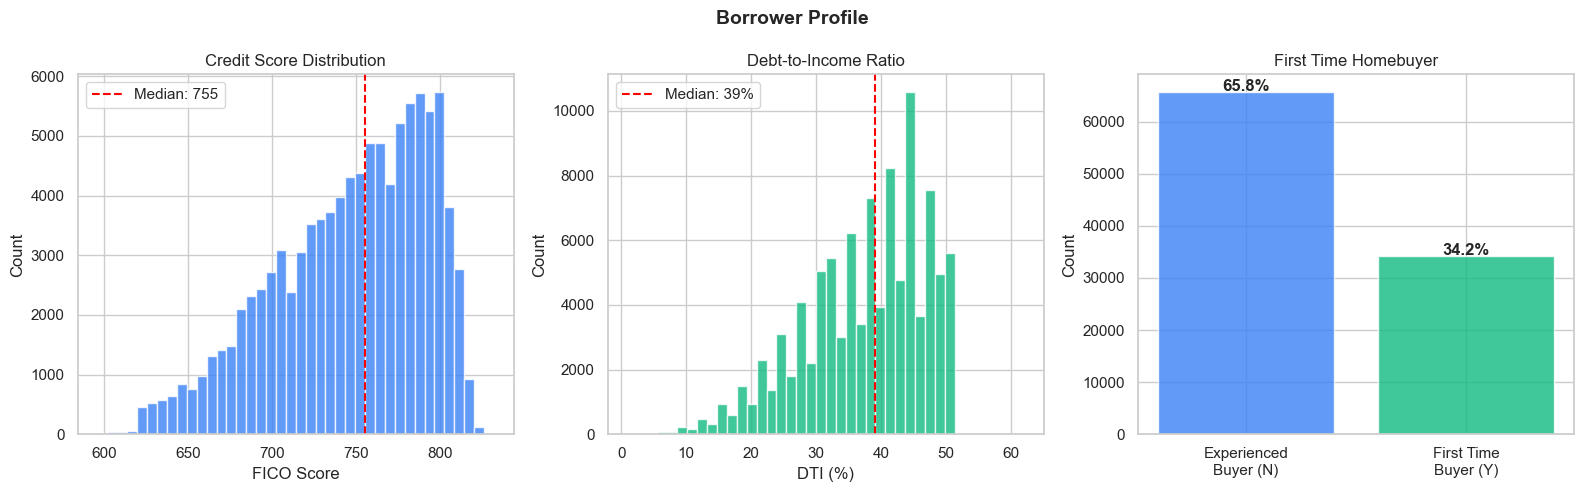

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Borrower Profile', fontsize=14, fontweight='bold')

# Credit Score
axes[0].hist(orig['credit_score'].dropna(), bins=40,
             color='#3b82f6', alpha=0.8, edgecolor='white')
axes[0].axvline(orig['credit_score'].median(), color='red',
                linestyle='--', linewidth=1.5,
                label=f"Median: {orig['credit_score'].median():.0f}")
axes[0].set_title('Credit Score Distribution')
axes[0].set_xlabel('FICO Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# DTI
axes[1].hist(orig['dti'].dropna(), bins=40,
             color='#10b981', alpha=0.8, edgecolor='white')
axes[1].axvline(orig['dti'].median(), color='red',
                linestyle='--', linewidth=1.5,
                label=f"Median: {orig['dti'].median():.0f}%")
axes[1].set_title('Debt-to-Income Ratio')
axes[1].set_xlabel('DTI (%)')
axes[1].set_ylabel('Count')
axes[1].legend()

# First Time Homebuyer
fthb = orig['first_time_homebuyer'].value_counts()
colors_fthb = ['#3b82f6', '#10b981']
axes[2].bar(['Experienced\nBuyer (N)', 'First Time\nBuyer (Y)'],
            fthb.values, color=colors_fthb, alpha=0.8)
for i, v in enumerate(fthb.values):
    axes[2].text(i, v + 200, f'{v/len(orig)*100:.1f}%',
                ha='center', fontweight='bold')
axes[2].set_title('First Time Homebuyer')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Borrower Profile Insights:**
- Median FICO of **755** — high-quality borrower pool, well above subprime threshold (620)
- Median DTI of **39%** — moderate debt burden; hard cap visible at 50% (Freddie Mac guideline)
- **34% first-time buyers** — significant segment requiring stricter underwriting scrutiny

## 3. Loan Characteristics  

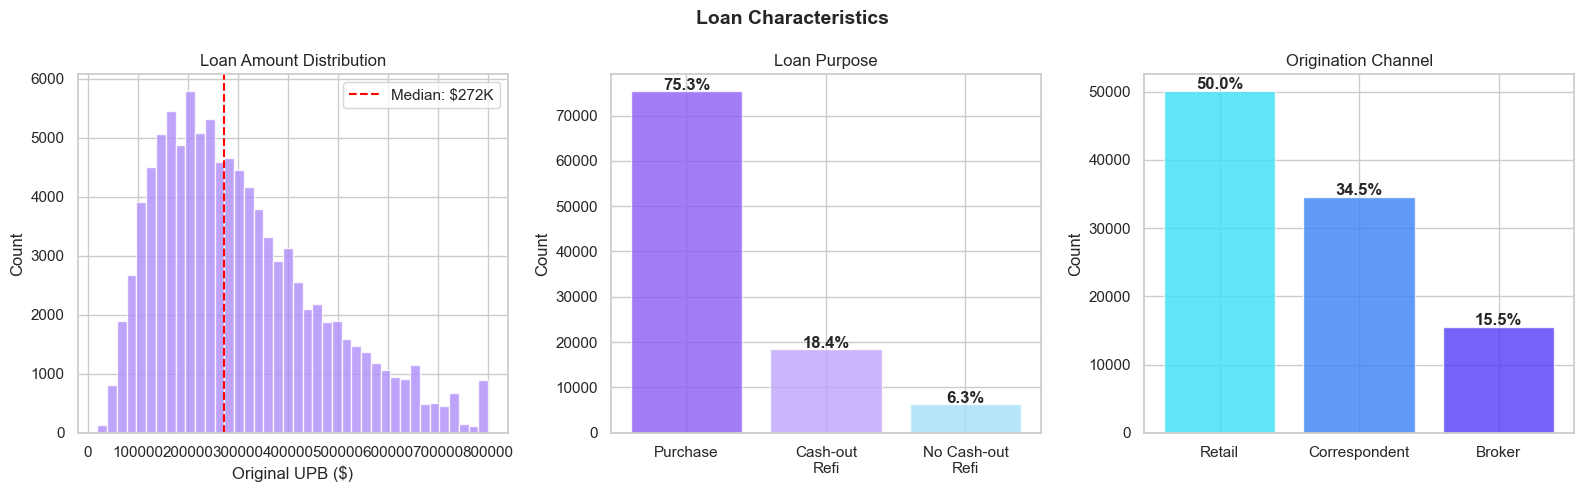

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Loan Characteristics', fontsize=14, fontweight='bold')

# Loan Amount
axes[0].hist(orig['orig_upb'].clip(upper=800000), bins=40,
             color='#ae8cf9', alpha=0.8, edgecolor='white')
axes[0].axvline(orig['orig_upb'].median(), color='red',
                linestyle='--', linewidth=1.5,
                label=f"Median: ${orig['orig_upb'].median()/1000:.0f}K")
axes[0].set_title('Loan Amount Distribution')
axes[0].set_xlabel('Original UPB ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Loan Purpose
purpose_map = {'P': 'Purchase', 'C': 'Cash-out\nRefi', 'N': 'No Cash-out\nRefi'}
purpose = orig['loan_purpose'].map(purpose_map).value_counts()
colors_p = ['#8c5bf6', '#bfa4fa', '#a4dffa']
bars = axes[1].bar(purpose.index, purpose.values, color=colors_p, alpha=0.8)
for bar, val in zip(bars, purpose.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                f'{val/len(orig)*100:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Loan Purpose')
axes[1].set_ylabel('Count')

# Origination Channel
channel_map = {'R': 'Retail', 'C': 'Correspondent', 'B': 'Broker'}
channel = orig['channel'].map(channel_map).value_counts()
colors_c = ['#3be0f6', '#3b82f6', '#523bf6']
bars2 = axes[2].bar(channel.index, channel.values, color=colors_c, alpha=0.8)
for bar, val in zip(bars2, channel.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                f'{val/len(orig)*100:.1f}%', ha='center', fontweight='bold')
axes[2].set_title('Origination Channel')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Loan Characteristics Insights:**
- Median loan size **$272K** — consistent with conforming loan limits
- **75% Purchase loans** — refinance activity collapsed due to rising rates in 2022-2023
- **50% Retail** channel dominates; Broker loans (15%) show highest default rate in EDA

## 4. Collateral Profile

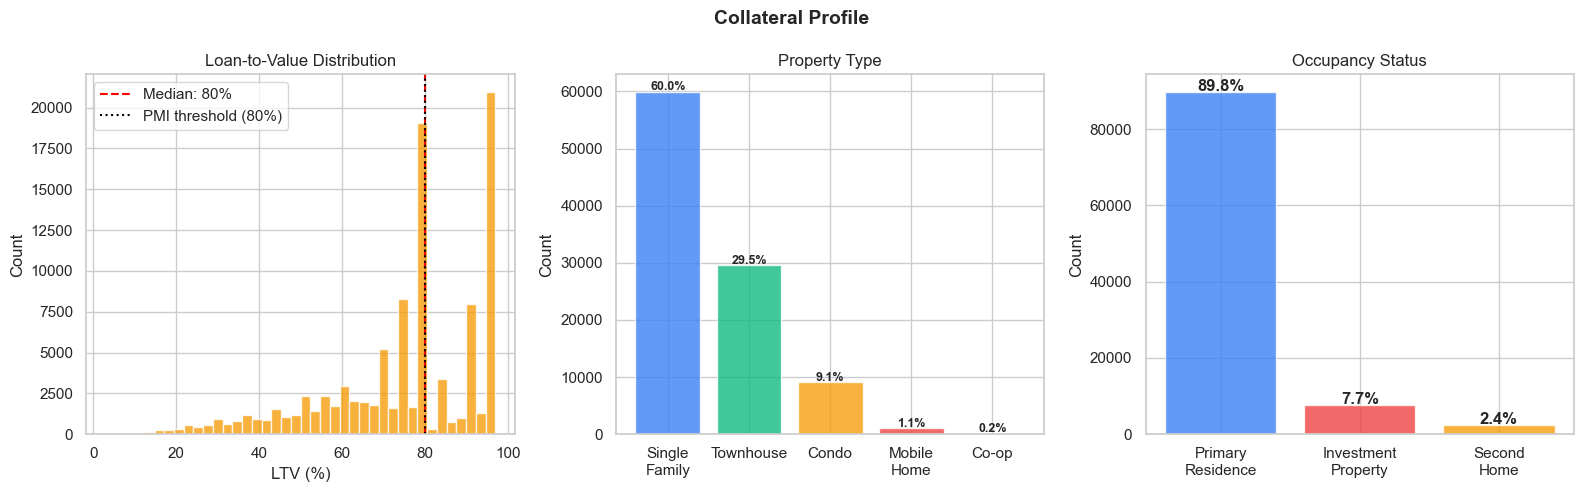

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Collateral Profile', fontsize=14, fontweight='bold')

# LTV Distribution
axes[0].hist(orig['oltv'].dropna(), bins=40,
             color='#f59e0b', alpha=0.8, edgecolor='white')
axes[0].axvline(orig['oltv'].median(), color='red',
                linestyle='--', linewidth=1.5,
                label=f"Median: {orig['oltv'].median():.0f}%")
axes[0].axvline(80, color='black', linestyle=':', linewidth=1.5,
                label='PMI threshold (80%)')
axes[0].set_title('Loan-to-Value Distribution')
axes[0].set_xlabel('LTV (%)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Property Type
prop_map = {'SF': 'Single\nFamily', 'PU': 'Townhouse',
            'CO': 'Condo', 'MH': 'Mobile\nHome', 'CP': 'Co-op'}
prop = orig['property_type'].map(prop_map).value_counts()
colors_prop = ['#3b82f6', '#10b981', '#f59e0b', '#ef4444', '#8b5cf6']
bars3 = axes[1].bar(prop.index, prop.values, color=colors_prop, alpha=0.8)
for bar, val in zip(bars3, prop.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{val/len(orig)*100:.1f}%', ha='center', fontweight='bold', fontsize=9)
axes[1].set_title('Property Type')
axes[1].set_ylabel('Count')

# Occupancy Status
occ_map = {'P': 'Primary\nResidence', 'I': 'Investment\nProperty', 'S': 'Second\nHome'}
occ = orig['occupancy_status'].map(occ_map).value_counts()
colors_occ = ['#3b82f6', '#ef4444', '#f59e0b']
bars4 = axes[2].bar(occ.index, occ.values, color=colors_occ, alpha=0.8)
for bar, val in zip(bars4, occ.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{val/len(orig)*100:.1f}%', ha='center', fontweight='bold')
axes[2].set_title('Occupancy Status')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Collateral Insights:**
- LTV peaks at **80% and 95-97%** — standard PMI thresholds drive clustering
- **60% Single Family** homes dominate; Mobile Homes (1.1%) show highest default rate (4.2%)
- **~90% Primary Residence** — investment properties are a small but higher-risk segment

## 5. Rate Environment (2022 vs 2023)

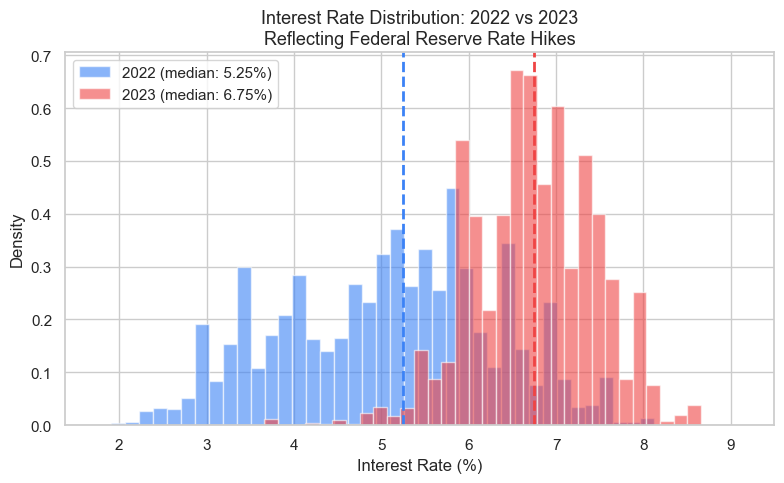

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

data_2022 = orig[orig['year'] == 2022]['orig_interest_rate']
data_2023 = orig[orig['year'] == 2023]['orig_interest_rate']

ax.hist(data_2022, bins=40, alpha=0.6, color='#3b82f6',
        label=f'2022 (median: {data_2022.median():.2f}%)', density=True)
ax.hist(data_2023, bins=40, alpha=0.6, color='#ef4444',
        label=f'2023 (median: {data_2023.median():.2f}%)', density=True)
ax.axvline(data_2022.median(), color='#3b82f6', linestyle='--', linewidth=2)
ax.axvline(data_2023.median(), color='#ef4444', linestyle='--', linewidth=2)
ax.set_title('Interest Rate Distribution: 2022 vs 2023\n'
             'Reflecting Federal Reserve Rate Hikes', fontsize=13)
ax.set_xlabel('Interest Rate (%)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

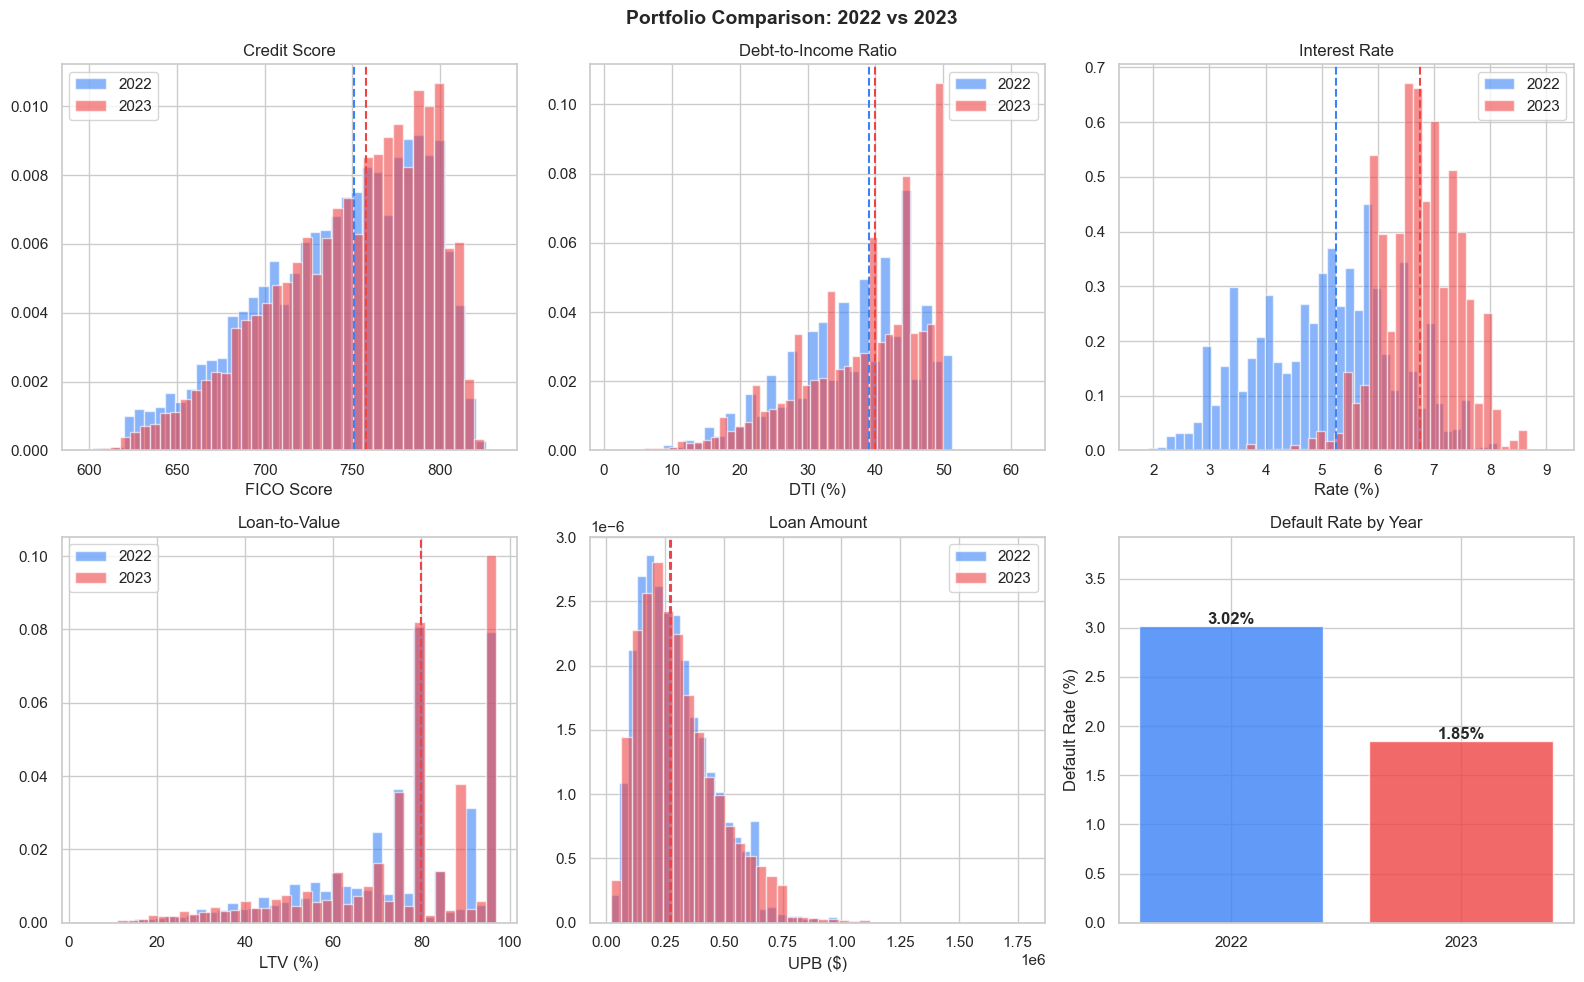

=== 2022 vs 2023 Key Metrics ===
      Avg FICO  Avg DTI  Avg Rate  Avg LTV    Avg UPB  Default Rate %
year                                                                 
2022   743.743   36.957     5.087   73.851  299407.94             3.0
2023   749.371   38.178     6.737   75.602  310956.72             1.8


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Portfolio Comparison: 2022 vs 2023', fontsize=14, fontweight='bold')

metrics = [
    ('credit_score', 'Credit Score', 'FICO Score'),
    ('dti', 'Debt-to-Income Ratio', 'DTI (%)'),
    ('orig_interest_rate', 'Interest Rate', 'Rate (%)'),
    ('oltv', 'Loan-to-Value', 'LTV (%)'),
    ('orig_upb', 'Loan Amount', 'UPB ($)'),
]

colors = {'2022': '#3b82f6', '2023': '#ef4444'}

for idx, (col, title, xlabel) in enumerate(metrics):
    ax = axes[idx // 3][idx % 3]
    for year, color in colors.items():
        data = orig[orig['year'] == int(year)][col].dropna()
        ax.hist(data, bins=40, alpha=0.6, color=color,
                label=str(year), density=True)
        ax.axvline(data.median(), color=color, linestyle='--', linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend()

# 6th plot — default rate comparison
ax = axes[1][2]
year_default = orig.groupby('year')['default'].mean() * 100
bars = ax.bar(year_default.index.astype(str), year_default.values,
              color=[colors['2022'], colors['2023']], alpha=0.8)
for bar, val in zip(bars, year_default.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}%', ha='center', fontweight='bold')
ax.set_title('Default Rate by Year')
ax.set_ylabel('Default Rate (%)')
ax.set_ylim(0, year_default.max() * 1.3)

plt.tight_layout()
plt.show()

print("=== 2022 vs 2023 Key Metrics ===")
comparison = orig.groupby('year')[
    ['credit_score', 'dti', 'orig_interest_rate', 'oltv', 'orig_upb', 'default']
].mean().round(3)
comparison['default'] = comparison['default'] * 100
comparison.columns = ['Avg FICO', 'Avg DTI', 'Avg Rate', 'Avg LTV', 'Avg UPB', 'Default Rate %']
print(comparison.to_string())

**Rate Environment:**
- Median rate rose from **5.09% (2022) → 6.74% (2023)** — a +165bps shift
- Directly reflects Federal Reserve hiking cycle: rates rose from 0.25% to 5.25% in 2022-2023
- Higher rates suppressed refinancing activity — explains why 75% of loans are purchases

## 6. Default Rate Analysis by Risk Factor

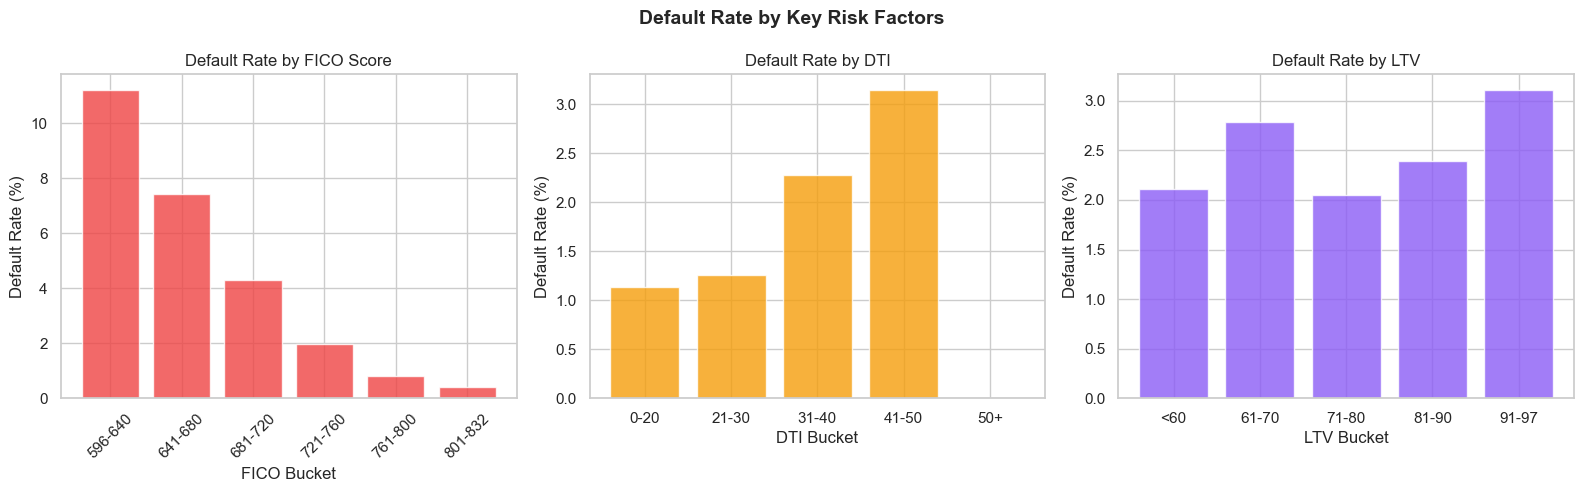

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Default Rate by Key Risk Factors', fontsize=14, fontweight='bold')

# 1. Default rate by credit score bucket
orig['credit_score_bucket'] = pd.cut(orig['credit_score'],
    bins=[596, 640, 680, 720, 760, 800, 832],
    labels=['596-640', '641-680', '681-720', '721-760', '761-800', '801-832'])

default_by_fico = orig.groupby('credit_score_bucket', observed=True)['default'].mean() * 100
axes[0].bar(default_by_fico.index, default_by_fico.values, color='#ef4444', alpha=0.8)
axes[0].set_title('Default Rate by FICO Score')
axes[0].set_xlabel('FICO Bucket')
axes[0].set_ylabel('Default Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

# 2. Default rate by DTI bucket
orig['dti_bucket'] = pd.cut(orig['dti'],
    bins=[0, 20, 30, 40, 50, 65],
    labels=['0-20', '21-30', '31-40', '41-50', '50+'])

default_by_dti = orig.groupby('dti_bucket', observed=True)['default'].mean() * 100
axes[1].bar(default_by_dti.index, default_by_dti.values, color='#f59e0b', alpha=0.8)
axes[1].set_title('Default Rate by DTI')
axes[1].set_xlabel('DTI Bucket')
axes[1].set_ylabel('Default Rate (%)')

# 3. Default rate by LTV bucket
orig['ltv_bucket'] = pd.cut(orig['oltv'],
    bins=[0, 60, 70, 80, 90, 97],
    labels=['<60', '61-70', '71-80', '81-90', '91-97'])

default_by_ltv = orig.groupby('ltv_bucket', observed=True)['default'].mean() * 100
axes[2].bar(default_by_ltv.index, default_by_ltv.values, color='#8b5cf6', alpha=0.8)
axes[2].set_title('Default Rate by LTV')
axes[2].set_xlabel('LTV Bucket')
axes[2].set_ylabel('Default Rate (%)')

plt.tight_layout()
plt.show()

## Key Risk Findings

### FICO Score — Strongest Predictor
- Borrowers with FICO 596-640 default at **11%** vs 0.4% for 800+
- 25x difference in default rate across credit score spectrum

### DTI — Clear Linear Relationship  
- Default rate triples from lowest (1.1%) to highest DTI bucket (3.1%)
- Hard cap at 50% DTI confirms Freddie Mac underwriting guidelines

### LTV — High Risk at Extremes
- Highest default rate at 91-97% LTV (3.1%) — minimal equity buffer
- Low LTV (<60%) also elevated — warrants further investigation

## 7. Correlation Analysis

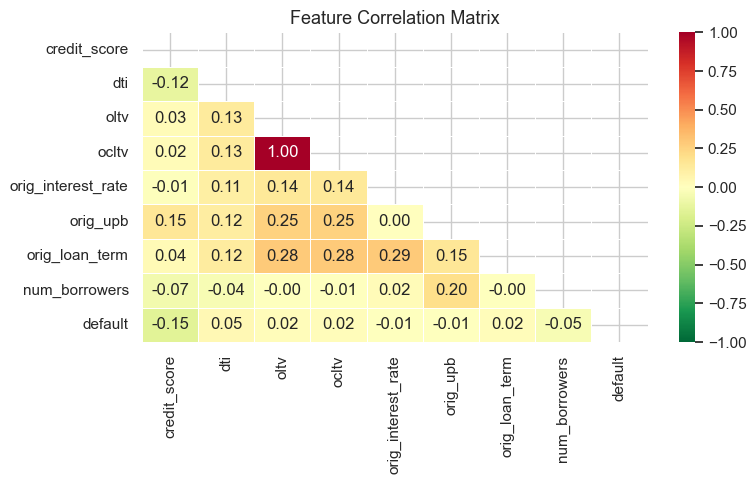

Top correlations with DEFAULT:
credit_score         -0.149568
num_borrowers        -0.046801
dti                   0.045506
ocltv                 0.023289
oltv                  0.022164
orig_loan_term        0.016030
orig_interest_rate   -0.007792
orig_upb             -0.007031
Name: default, dtype: float64


In [11]:
# ────────────── Correlation Heatmap ─────────────────
num_cols = ['credit_score', 'dti', 'oltv', 'ocltv',
            'orig_interest_rate', 'orig_upb', 'orig_loan_term',
            'num_borrowers', 'default']

corr = orig[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn_r', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

print("Top correlations with DEFAULT:")
print(corr['default'].drop('default').sort_values(key=abs, ascending=False))

**Key correlations with default:**
- `credit_score` shows strongest negative correlation (-0.15) — higher score = lower risk
- `dti` positive correlation (0.05) — higher debt burden = higher risk
- `oltv` and `ocltv` highly correlated (0.9+) — multicollinearity to address in modeling

## 8. Geographic Analysis

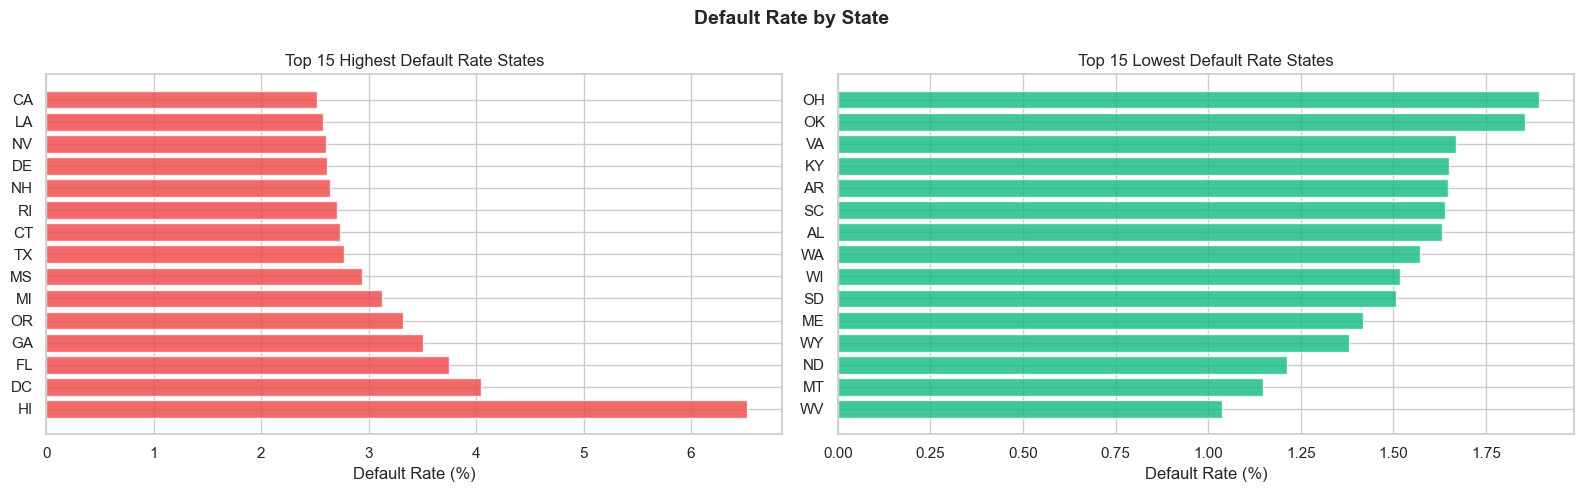


Top 10 states by default rate:
property_state  total_loans  default_rate  avg_credit_score   avg_dti
            HI          184      6.521739        746.934426 39.461957
            DC          173      4.046243        757.601156 37.017341
            FL         8797      3.751279        745.713279 38.825830
            GA         3735      3.507363        741.930120 37.464793
            OR         1387      3.316510        755.028118 37.945926
            MI         3619      3.122410        742.040895 36.603648
            MS          409      2.933985        743.124694 36.205379
            TX         9776      2.772095        743.350077 37.974629
            CT         1099      2.729754        741.024568 38.215651
            RI          259      2.702703        740.644788 38.281853


In [12]:
state_stats = orig.groupby('property_state').agg(
    total_loans=('default', 'count'),
    default_rate=('default', 'mean'),
    avg_credit_score=('credit_score', 'mean'),
    avg_dti=('dti', 'mean')
).reset_index()

state_stats = state_stats[state_stats['total_loans'] >= 100]
state_stats['default_rate'] = state_stats['default_rate'] * 100

top_default = state_stats.nlargest(15, 'default_rate')
low_default = state_stats.nsmallest(15, 'default_rate')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Default Rate by State', fontsize=14, fontweight='bold')

axes[0].barh(top_default['property_state'], top_default['default_rate'],
             color='#ef4444', alpha=0.8)
axes[0].set_title('Top 15 Highest Default Rate States')
axes[0].set_xlabel('Default Rate (%)')

axes[1].barh(low_default['property_state'], low_default['default_rate'],
             color='#10b981', alpha=0.8)
axes[1].set_title('Top 15 Lowest Default Rate States')
axes[1].set_xlabel('Default Rate (%)')

plt.tight_layout()
plt.show()

print("\nTop 10 states by default rate:")
print(state_stats.nlargest(10, 'default_rate')[
    ['property_state', 'total_loans', 'default_rate', 'avg_credit_score', 'avg_dti']
].to_string(index=False))

## Geographic Risk Analysis

- **Hawaii (HI)** shows anomalously high default rate (6.5%) despite average FICO 747
    likely driven by high property values and market volatility
- **FL, GA, DC** cluster as high-risk states 
- **Rural states (WV, MT, ND)** show lowest default rates 


## 9. Categorical Features Analysis

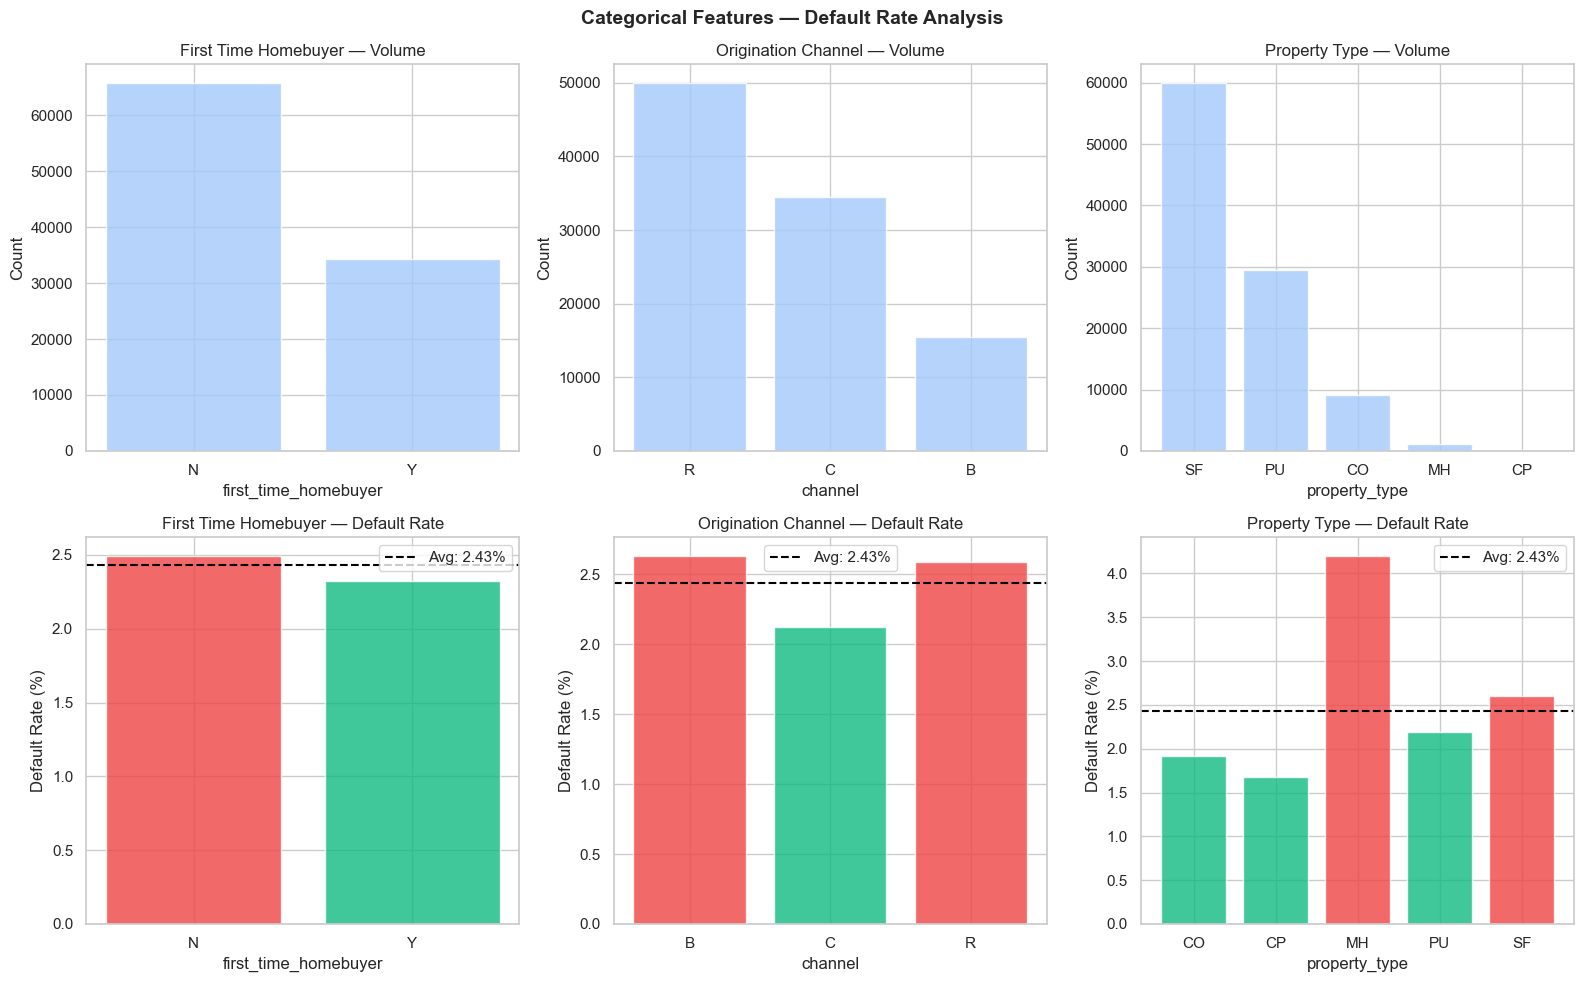


=== First Time Homebuyer ===
                      count  default_rate  share_%
first_time_homebuyer                              
N                     65770          2.49    65.77
Y                     34230          2.32    34.23

=== Origination Channel ===
         count  default_rate  share_%
channel                              
B        15469          2.63    15.47
C        34526          2.12    34.53
R        50005          2.59    50.00

=== Property Type ===
               count  default_rate  share_%
property_type                              
CO              9142          1.91     9.14
CP               239          1.67     0.24
MH              1095          4.20     1.10
PU             29546          2.19    29.55
SF             59978          2.60    59.98


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Categorical Features — Default Rate Analysis', fontsize=14, fontweight='bold')

cat_features = [
    ('first_time_homebuyer', 'First Time Homebuyer'),
    ('channel', 'Origination Channel'),
    ('property_type', 'Property Type'),
]

for idx, (col, title) in enumerate(cat_features):
    # Count plot
    ax_top = axes[0][idx]
    counts = orig[col].value_counts()
    ax_top.bar(counts.index, counts.values, color='#a4cafa', alpha=0.8)
    ax_top.set_title(f'{title} — Volume')
    ax_top.set_xlabel(col)
    ax_top.set_ylabel('Count')

    # Default rate plot
    ax_bot = axes[1][idx]
    default_by_cat = orig.groupby(col)['default'].mean() * 100
    colors = ['#ef4444' if v > orig['default'].mean() * 100 else '#10b981'
              for v in default_by_cat.values]
    ax_bot.bar(default_by_cat.index, default_by_cat.values, color=colors, alpha=0.8)
    ax_bot.axhline(orig['default'].mean() * 100, color='black',
                   linestyle='--', linewidth=1.5, label=f"Avg: {orig['default'].mean()*100:.2f}%")
    ax_bot.set_title(f'{title} — Default Rate')
    ax_bot.set_xlabel(col)
    ax_bot.set_ylabel('Default Rate (%)')
    ax_bot.legend()

plt.tight_layout()
plt.show()

# Print summary table
for col, title in cat_features:
    print(f"\n=== {title} ===")
    summary = orig.groupby(col).agg(
        count=('default', 'count'),
        default_rate=('default', 'mean')
    )
    summary['default_rate'] = summary['default_rate'] * 100
    summary['share_%'] = summary['count'] / len(orig) * 100
    print(summary.round(2).to_string())

## Categorical Features — Key Findings

### Origination Channel
- Correspondent (C) loans show lowest default rate (2.12%) 
  — correspondent lenders retain skin-in-the-game, incentivizing quality
- Broker (B) and Retail (R) channels are above average (2.63%, 2.59%)

### Property Type
- Mobile Homes (MH) default at 4.20% — nearly 2x the portfolio average
  — lower liquidity, harder to sell = higher loss severity on default
- Condos (CO) show lowest default rate (1.91%) — urban, higher-income borrowers

### First Time Homebuyer
- Minimal difference (2.32% vs 2.49%) — first-time buyers are not higher risk
  — likely due to stricter underwriting requirements for this segment

## 10. Key Findings Summary

### Portfolio Overview
- **100,000 mortgage loans** originated in 2022–2023 with **2.43% default rate**
- Portfolio is high-quality: median FICO 755, median DTI 39%, median LTV 80%

### Borrower Risk Drivers
| Factor | Low Risk | High Risk | Default Rate Difference |
|--------|----------|-----------|------------------------|
| FICO Score | 801-832 | 596-640 | 0.4% vs 11.2% — **28x** |
| DTI | 0-20% | 41-50% | 1.1% vs 3.1% — **3x** |
| LTV | 71-80% | 91-97% | 2.1% vs 3.1% — **1.5x** |

### Loan & Property Risk Drivers
- **Mobile Homes (MH)** default at **4.2%** — nearly 2x portfolio average
- **Broker channel** shows highest default rate (2.63%) vs Correspondent (2.12%)
- **Cash-out refinance** loans are riskier than purchase loans
- **Joint loans** (2 borrowers) show lower default risk than single borrower

### Geographic Risk
- **Hawaii (HI)** anomalously high at **6.5%** despite average FICO 747
- **FL, GA, DC** cluster as high-risk states (3.5–4.0%)
- **Rural states (WV, MT, ND)** lowest default rates (<1.1%)

### Market Environment (2022 vs 2023)
- Interest rates rose **+165bps** (5.09% → 6.74%) reflecting Fed hiking cycle
- Purchase loans dominate (**75%**) — refinance activity collapsed under high rates
- 2023 loans show lower observed default (1.85%) due to loan immaturity — not improved quality

### Modeling Implications
- FICO score, DTI, and LTV are primary features for default prediction
- Geographic and channel variables add incremental predictive value
- Class imbalance (40:1) must be addressed in modeling phase